In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("loan_risk_dataset.csv")

In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LN0000,Male,No,2,Not Graduate,Yes,17262,7847.23,315,120,1.0,Semiurban,N
1,LN0001,Female,Yes,2,Not Graduate,No,20994,8264.54,635,240,0.0,Rural,Y
2,LN0002,Male,Yes,2,Graduate,Yes,20050,9137.65,543,180,1.0,Semiurban,Y
3,LN0003,Male,No,2,Not Graduate,No,10026,8799.30,382,180,1.0,Rural,Y
4,LN0004,Male,No,3+,Graduate,No,17398,9997.41,462,120,1.0,Urban,N


In [8]:
# Get the shape of the dataset
print("Shape:", df.shape)

Shape: (2500, 13)


In [9]:
# Show column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            2500 non-null   object 
 1   Gender             2500 non-null   object 
 2   Married            2500 non-null   object 
 3   Dependents         2500 non-null   object 
 4   Education          2500 non-null   object 
 5   Self_Employed      2500 non-null   object 
 6   ApplicantIncome    2500 non-null   int64  
 7   CoapplicantIncome  2500 non-null   float64
 8   LoanAmount         2500 non-null   int64  
 9   Loan_Amount_Term   2500 non-null   int64  
 10  Credit_History     2500 non-null   float64
 11  Property_Area      2500 non-null   object 
 12  Loan_Status        2500 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 254.0+ KB


In [10]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [11]:
# Check unique values in Credit_History (important for risk)
print("Credit_History values:", df['Credit_History'].unique())

Credit_History values: [1. 0.]


In [12]:
# Define a function to categorize risk
def assign_risk(row):
    if row['Credit_History'] == 0.0:
        return 'High'
    elif row['ApplicantIncome'] < 5000 and row['LoanAmount'] > 300:
        return 'Medium'
    else:
        return 'Low'

In [13]:
# Apply function to each row
df['Risk_Level'] = df.apply(assign_risk, axis=1)

In [14]:

# Check result
df['Risk_Level'].value_counts()

Risk_Level
Low       1818
High       495
Medium     187
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_12352\2159707703.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', palette='Set2')


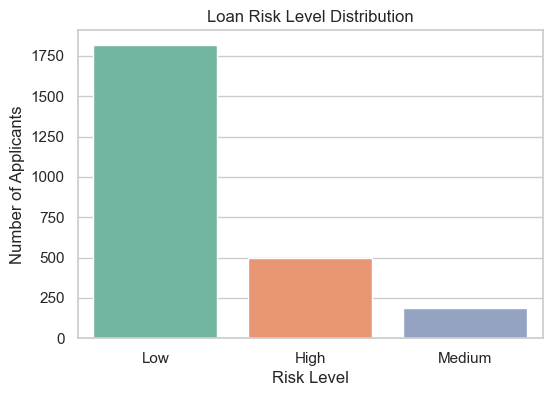

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Risk_Level', palette='Set2')
plt.title('Loan Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Applicants')
plt.savefig("Loan Risk Level Distribution.png" , dpi = 300 )
plt.show()


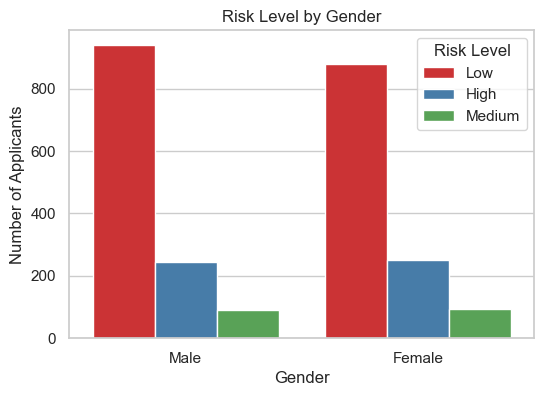

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', hue='Risk_Level', palette='Set1')
plt.title('Risk Level by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Level')
plt.savefig("Risk Level by Gender.png" , dpi = 300)
plt.show()


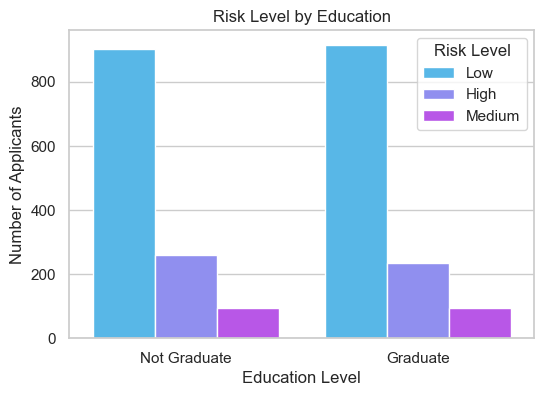

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Education', hue='Risk_Level', palette='cool')
plt.title('Risk Level by Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Level')
plt.savefig("Risk Level by Education.png", dpi = 300)
plt.show()


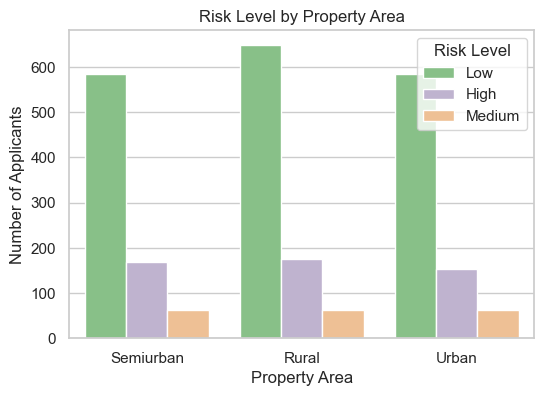

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Property_Area', hue='Risk_Level', palette='Accent')
plt.title('Risk Level by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Number of Applicants')
plt.legend(title='Risk Level')
plt.savefig("Risk Level by Property Area.png" ,dpi = 300)
plt.show()


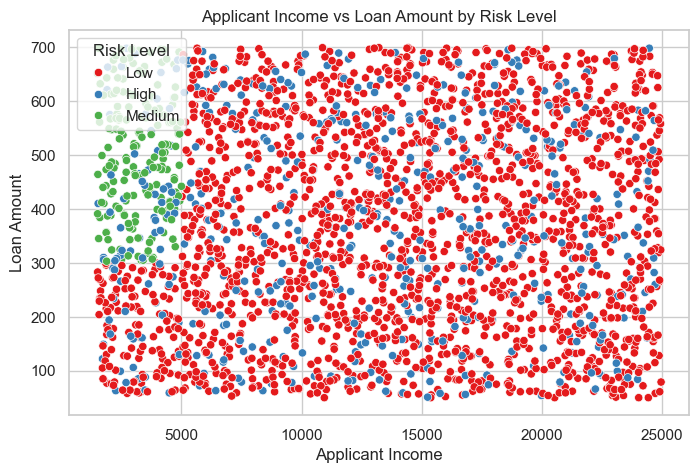

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Risk_Level', palette='Set1')
plt.title('Applicant Income vs Loan Amount by Risk Level')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend(title='Risk Level')
plt.savefig("Applicant Income vs Loan Amount by Risk Level.png", dpi=300)
plt.show()
